# 建模与评估（modeling.ipynb）

本 notebook 读取 `cleaned_full.csv`（由 `data_preprocessing.ipynb` 生成），进行特征选择、标准化，并实现三种划分方法：留出法、交叉验证、自助法（Bootstrap），使用 Logistic Regression 作为示例模型，并保存评估图。

In [8]:
# 导入库
import os
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
%matplotlib inline
from sklearn.model_selection import train_test_split, StratifiedKFold
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import confusion_matrix, roc_curve, auc, classification_report
from sklearn.preprocessing import StandardScaler, LabelEncoder
from sklearn.utils import resample

In [9]:
# 读取清洗后的全量数据（确保已运行 data_preprocessing.ipynb）
path = 'cleaned_full.csv'
if not os.path.exists(path):
    raise FileNotFoundError(f'{path} 未找到，请先运行 data_preprocessing.ipynb 生成该文件')
df = pd.read_csv(path)
print('读取 cleaned_full.csv，形状：', df.shape)
df.head()

读取 cleaned_full.csv，形状： (300, 23)


,Unnamed: 0,序号,性别,年龄,右侧血压（mmHg）,身高,体重,腰围,体质指数,吸烟状况,...,总胆固醇,甘油三酯,血清低密度脂蛋白胆固醇,血淸高密度脂蛋白胆固醇,B超,右侧收缩压,右侧舒张压,合并心电图描述,合并B超描述,风险类别
0,109,112,男,35,114/67,166.0,65.4,80,23.73,吸烟,...,3.34,0.88,1.34,2.44,正常,114,67,正常,正常,低风险
1,126,130,男,35,123/75,165.5,60.1,75,21.94,从不吸烟,...,3.77,0.75,0.64,3.87,正常,123,75,正常,正常,低风险
2,66,67,男,35,75/37,169.0,63.2,75,22.13,吸烟,...,3.08,0.48,1.11,2.09,正常,75,37,过缓,正常,低风险
3,220,224,男,36,107/59,168.0,88.4,96,31.32,已戒烟,...,2.10,0.00,2.40,1.03,脂肪肝,107,59,正常,肝,低风险
4,98,101,男,35,130/70,170.5,62.0,79,21.33,从不吸烟,...,3.59,1.39,1.06,3.04,正常,130,70,正常,正常,低风险


In [10]:
# 自动选择数值特征（示例）
num_cols = df.select_dtypes(include=[np.number]).columns.tolist()
# 排除不作为特征的列（如果存在）
exclude = []
features = [c for c in num_cols if c not in exclude]
print('选择作为特征的列（示例）：', features)
X = df[features].fillna(df[features].median())
le = LabelEncoder()
y = le.fit_transform(df['风险类别'].astype(str))
scaler = StandardScaler()
Xs = scaler.fit_transform(X)

选择作为特征的列（示例）： ['Unnamed: 0', '序号', '年龄', '身高', '体重', '腰围', '体质指数', '空腹血糖MMOL', '总胆固醇', '甘油三酯', '血清低密度脂蛋白胆固醇', '血淸高密度脂蛋白胆固醇', '右侧收缩压', '右侧舒张压']


Classification report (hold-out):
              precision    recall  f1-score   support

           0       1.00      0.98      0.99        54
           1       0.86      1.00      0.92         6

    accuracy                           0.98        60
   macro avg       0.93      0.99      0.96        60
weighted avg       0.99      0.98      0.98        60

Saved fig_confusion.png
Saved fig_confusion.png


<Figure size 500x400 with 0 Axes>

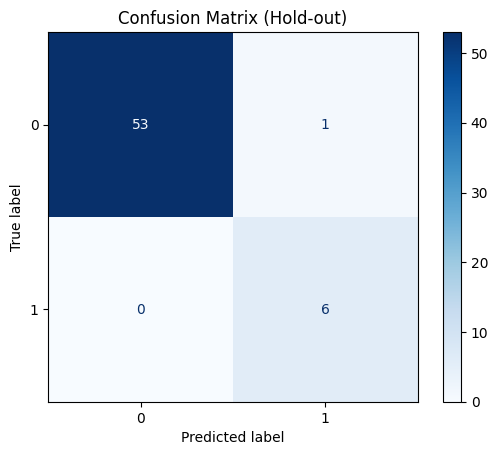

In [11]:
# 留出法：80/20（分层）
X_train, X_test, y_train, y_test = train_test_split(Xs, y, test_size=0.2, random_state=42, stratify=y)
clf = LogisticRegression(max_iter=200)
clf.fit(X_train, y_train)
y_pred = clf.predict(X_test)
print('Classification report (hold-out):')
print(classification_report(y_test, y_pred))
cm = confusion_matrix(y_test, y_pred)
from sklearn.metrics import ConfusionMatrixDisplay
plt.figure(figsize=(5,4))
ConfusionMatrixDisplay(cm).plot(cmap='Blues', values_format='d')
plt.title('Confusion Matrix (Hold-out)')
plt.savefig('fig_confusion.png', bbox_inches='tight')
print('Saved fig_confusion.png')

Saved fig_roc.png


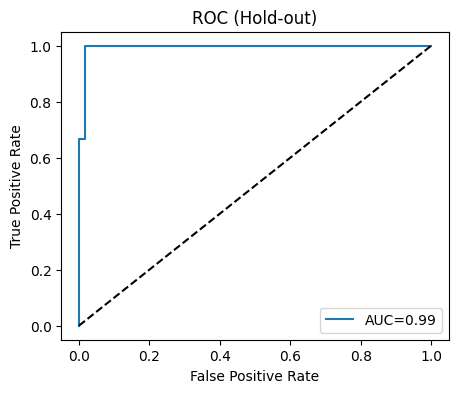

In [12]:
# ROC（若二分类）
if len(np.unique(y))==2:
    y_score = clf.predict_proba(X_test)[:,1]
    fpr, tpr, _ = roc_curve(y_test, y_score)
    roc_auc = auc(fpr, tpr)
    plt.figure(figsize=(5,4))
    plt.plot(fpr,tpr,label=f'AUC={roc_auc:.2f}')
    plt.plot([0,1],[0,1],'k--')
    plt.xlabel('False Positive Rate')
    plt.ylabel('True Positive Rate')
    plt.title('ROC (Hold-out)')
    plt.legend()
    plt.savefig('fig_roc.png', bbox_inches='tight')
    print('Saved fig_roc.png')

In [13]:
# 交叉验证（5 折分层）
skf = StratifiedKFold(n_splits=5, shuffle=True, random_state=42)
accs = []
for tr_idx, te_idx in skf.split(Xs, y):
    m = LogisticRegression(max_iter=200)
    m.fit(Xs[tr_idx], y[tr_idx])
    accs.append(m.score(Xs[te_idx], y[te_idx]))
print('5-fold CV accuracy mean/std:', np.mean(accs), np.std(accs))

5-fold CV accuracy mean/std: 0.9566666666666667 0.02708012801545319


In [14]:
# 自助法（Bootstrap）示例
n_boot = 30
boot_scores = []
for i in range(n_boot):
    Xb, yb = resample(Xs, y, replace=True, n_samples=len(y), random_state=42+i)
    # OOB（近似）
    oob_mask = ~np.isin(range(len(y)), np.unique(resample(range(len(y)), replace=True, n_samples=len(y), random_state=42+i)))
    if oob_mask.sum() < 5:
        continue
    clf_b = LogisticRegression(max_iter=200)
    clf_b.fit(Xb, yb)
    try:
        score = clf_b.score(Xs[oob_mask], y[oob_mask])
        boot_scores.append(score)
    except Exception:
        pass
print('Bootstrap mean/std:', np.mean(boot_scores) if boot_scores else None, np.std(boot_scores) if boot_scores else None)

Bootstrap mean/std: 0.9508353771094943 0.02166768290703864


---
完成：混淆矩阵与 ROC 图已保存为 `fig_confusion.png`、`fig_roc.png`。若需要更多模型对比（随机森林、XGBoost 等），可在此 notebook 中加入对应代码单元。